# tactical-asset-allocation-lstm

**Author:** Sana Ur Rehman  
**Profession:** Data Scientist  
**Created:** 2026  

---

## License

This project is licensed under the **MIT License**. 

You are free to use, modify, distribute, and build upon this work for both commercial and non-commercial purposes, provided you give appropriate **credit** to the original author. For the full legal text and conditions, please refer to the `LICENSE` file included in this project's repository.

---

## Citation

If you reference or build upon this project, please provide appropriate credit.

For formal citation information, please see the project's `README.md` and `CITATION.cff` files.

# Step 2: Single-output LSTM models

In [1]:
import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)


C:\Users\Yahya\AppData\Roaming\Python\Python313\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
C:\Users\Yahya\AppData\Roaming\Python\Python313\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
C:\Users\Yahya\AppData\Roaming\Python\Python313\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/resource_handle.proto. Please 

In [2]:
ret_train = pd.read_csv("data/returns_train.csv", index_col=0, parse_dates=True)
ret_val   = pd.read_csv("data/returns_val.csv",   index_col=0, parse_dates=True)
ret_test  = pd.read_csv("data/returns_test.csv",  index_col=0, parse_dates=True)

y_train = pd.read_csv("data/target_train.csv", index_col=0, parse_dates=True)
y_val   = pd.read_csv("data/target_val.csv",   index_col=0, parse_dates=True)
y_test  = pd.read_csv("data/target_test.csv",  index_col=0, parse_dates=True)

assets = list(ret_train.columns)
assets

['Equity (SPY)',
 'Long Treasuries (TLT)',
 'Short Treasuries (SHY)',
 'Gold (GLD)',
 'Oil (DBO)']

Feature engineering (lags + optional rolling features)

In [3]:
LOOKBACK = 60  # 60 trading days (~3 months). You can tune later.
USE_ROLLING = True

def build_features(returns_df):
    X = returns_df.copy()
    if USE_ROLLING:
        # rolling volatility + momentum proxies
        for w in [5, 21, 63]:
            X = X.join(returns_df.rolling(w).mean().add_suffix(f"_mean{w}"))
            X = X.join(returns_df.rolling(w).std().add_suffix(f"_vol{w}"))
    X = X.dropna()
    return X

X_train_df = build_features(ret_train)
X_val_df   = build_features(ret_val)
X_test_df  = build_features(ret_test)

# Align targets to feature indexes (important because rolling drops rows)
y_train_al = y_train.loc[X_train_df.index]
y_val_al   = y_val.loc[X_val_df.index]
y_test_al  = y_test.loc[X_test_df.index]

X_train_df.shape, X_val_df.shape, X_test_df.shape

((1699, 35), (189, 35), (1172, 35))

Scaling (fit on train only)

In [4]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_df)
X_val_scaled   = scaler.transform(X_val_df)
X_test_scaled  = scaler.transform(X_test_df)

Sequence builder (LSTM expects 3D: samples × timesteps × features)

In [5]:
def make_sequences(X_scaled, y_df_one_asset, lookback):
    """
    X_scaled: np.array (T, n_features)
    y_df_one_asset: pd.Series aligned with X (T,)
    Returns:
      X_seq: (N, lookback, n_features)
      y_seq: (N,)
      idx:   index timestamps for y_seq (useful for plotting)
    """
    y_arr = y_df_one_asset.values.astype(np.float32)
    X_arr = X_scaled.astype(np.float32)

    X_seq, y_seq, idx = [], [], []
    for t in range(lookback, len(X_arr)):
        X_seq.append(X_arr[t-lookback:t, :])
        y_seq.append(y_arr[t])
        idx.append(y_df_one_asset.index[t])

    return np.array(X_seq), np.array(y_seq), pd.to_datetime(idx)

Model factory (compact, strong baseline)

In [6]:
def build_lstm_model(n_features, lookback, lr=1e-3, lstm_units=64, dropout=0.2):
    model = keras.Sequential([
        layers.Input(shape=(lookback, n_features)),
        layers.LSTM(lstm_units, return_sequences=False),
        layers.Dropout(dropout),
        layers.Dense(32, activation="relu"),
        layers.Dense(1)  # regression
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="mse",
        metrics=[keras.metrics.MeanAbsoluteError(name="mae")]
    )
    return model

Train + evaluate a single asset model (helper)

Metrics we’ll compute:

- MSE, RMSE, MAE, R²

- Directional accuracy = % of times sign(pred) == sign(actual)

In [7]:
def directional_accuracy(y_true, y_pred):
    return (np.sign(y_true) == np.sign(y_pred)).mean()

def train_and_eval_for_asset(asset_name, epochs=60, batch_size=32):
    # Build sequences for this asset
    Xtr, ytr, idx_tr = make_sequences(X_train_scaled, y_train_al[asset_name], LOOKBACK)
    Xva, yva, idx_va = make_sequences(X_val_scaled,   y_val_al[asset_name],   LOOKBACK)
    Xte, yte, idx_te = make_sequences(X_test_scaled,  y_test_al[asset_name],  LOOKBACK)

    n_features = Xtr.shape[-1]
    model = build_lstm_model(n_features=n_features, lookback=LOOKBACK)

    callbacks = [
        keras.callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-5),
    ]

    hist = model.fit(
        Xtr, ytr,
        validation_data=(Xva, yva),
        epochs=epochs,
        batch_size=batch_size,
        verbose=0,
        callbacks=callbacks
    )

    # Predictions
    pred_tr = model.predict(Xtr, verbose=0).ravel()
    pred_va = model.predict(Xva, verbose=0).ravel()
    pred_te = model.predict(Xte, verbose=0).ravel()

    # Metrics
    def pack_metrics(y, p):
        mse = mean_squared_error(y, p)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(y, p)
        r2 = r2_score(y, p)
        da = directional_accuracy(y, p)
        return mse, rmse, mae, r2, da

    m_tr = pack_metrics(ytr, pred_tr)
    m_va = pack_metrics(yva, pred_va)
    m_te = pack_metrics(yte, pred_te)

    metrics = pd.DataFrame(
        [m_tr, m_va, m_te],
        columns=["MSE","RMSE","MAE","R2","DirectionalAcc"],
        index=["Train","Validation","Test"]
    )

    # Return everything we need for plots + later trading strategy
    preds_test = pd.Series(pred_te, index=idx_te, name=f"pred_{asset_name}")
    actual_test = pd.Series(yte, index=idx_te, name=f"actual_{asset_name}")

    return model, hist, metrics, preds_test, actual_test

Train all 5 single-output LSTMs + save predictions

In [8]:
os.makedirs("outputs", exist_ok=True)

all_metrics = {}
preds_test_all = []
actual_test_all = []
models = {}
histories = {}  

for asset in assets:
    print(f"Training LSTM for: {asset}")
    model, hist, metrics, pred_te, act_te = train_and_eval_for_asset(asset)

    models[asset] = model
    histories[asset] = hist          
    all_metrics[asset] = metrics

    preds_test_all.append(pred_te)
    actual_test_all.append(act_te)

    display(metrics)
    print("-"*60)

preds_test_df = pd.concat(preds_test_all, axis=1)
actual_test_df = pd.concat(actual_test_all, axis=1)

preds_test_df.to_csv("outputs/step2_single_output_predictions.csv")
actual_test_df.to_csv("outputs/step2_single_output_actuals.csv")

print("Saved:")
print(" - outputs/step2_single_output_predictions.csv")
print(" - outputs/step2_single_output_actuals.csv")

Training LSTM for: Equity (SPY)


,MSE,RMSE,MAE,R2,DirectionalAcc
Train,0.001226,0.035014,0.027384,0.161534,0.744356
Validation,0.001795,0.042373,0.034659,-4.287386,0.488372
Test,0.008236,0.090751,0.065873,-1.001179,0.585432


------------------------------------------------------------
Training LSTM for: Long Treasuries (TLT)


,MSE,RMSE,MAE,R2,DirectionalAcc
Train,0.000388,0.019689,0.015771,0.777170,0.836486
Validation,0.001269,0.035627,0.028429,-1.886793,0.581395
Test,0.005229,0.072310,0.055964,-1.181462,0.517986


------------------------------------------------------------
Training LSTM for: Short Treasuries (SHY)


...

------------------------------------------------------------
Training LSTM for: Gold (GLD)


,MSE,RMSE,MAE,R2,DirectionalAcc
Train,0.000495,0.022247,0.017871,0.819263,0.827334
Validation,0.001779,0.042183,0.033511,-0.765218,0.426357
Test,0.005407,0.073530,0.058836,-2.162737,0.449640


------------------------------------------------------------
Training LSTM for: Oil (DBO)


,MSE,RMSE,MAE,R2,DirectionalAcc
Train,0.001779,0.042174,0.033660,0.787622,0.818182
Validation,0.014212,0.119214,0.103730,-7.974783,0.147287
Test,0.016103,0.126897,0.102095,-0.238447,0.553957


------------------------------------------------------------
Saved:
 - outputs/step2_single_output_predictions.csv
 - outputs/step2_single_output_actuals.csv


Required plots: loss curves + predicted vs actual (test)
- (a) Training curves per asset

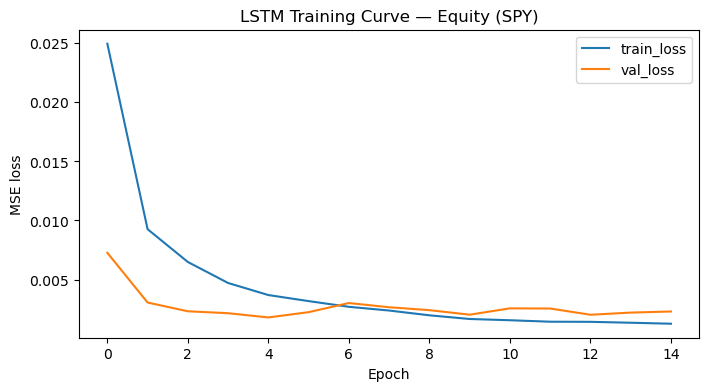

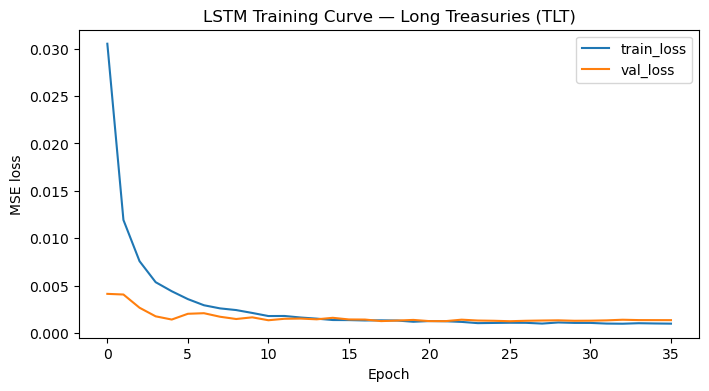

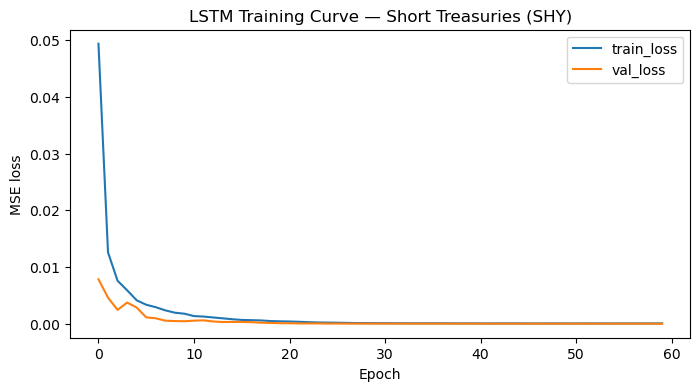

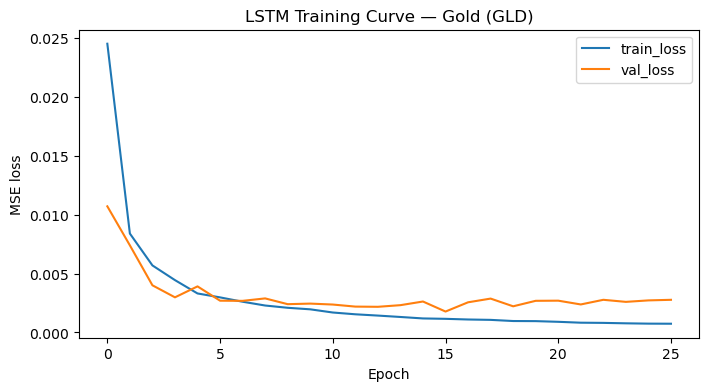

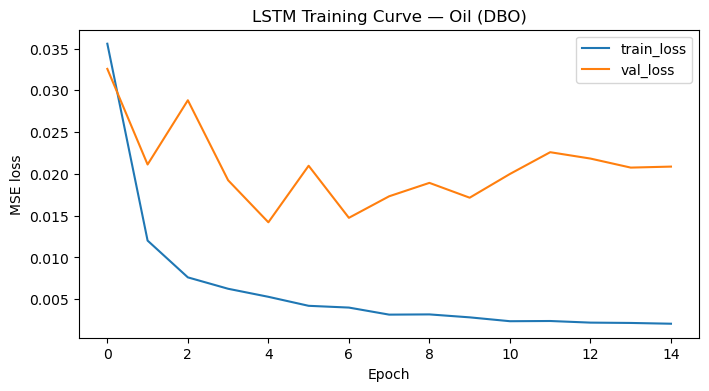

In [9]:
def plot_history(hist, title):
    plt.figure(figsize=(8,4))
    plt.plot(hist.history["loss"], label="train_loss")
    plt.plot(hist.history["val_loss"], label="val_loss")
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("MSE loss")
    plt.legend()
    plt.show()

for asset in assets:
    plot_history(histories[asset], f"LSTM Training Curve — {asset}")

- (b) Predicted vs actual (test sample)

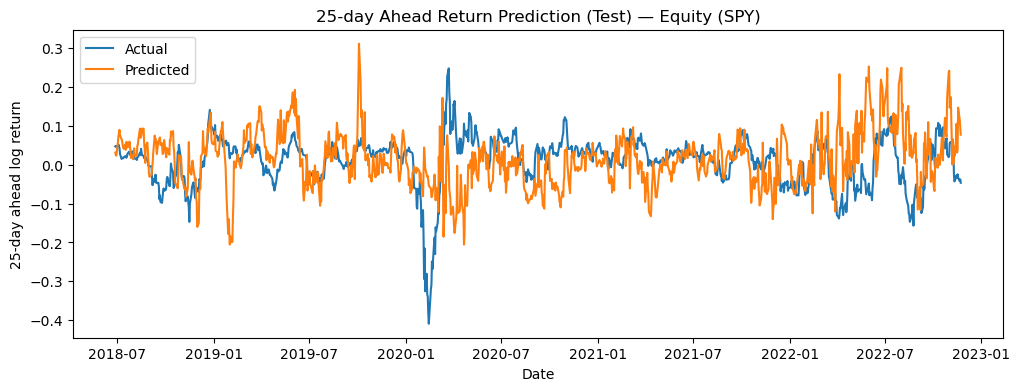

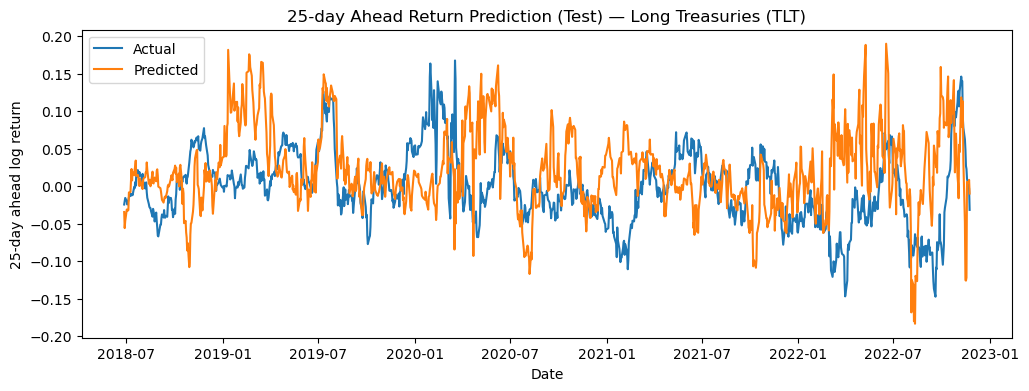

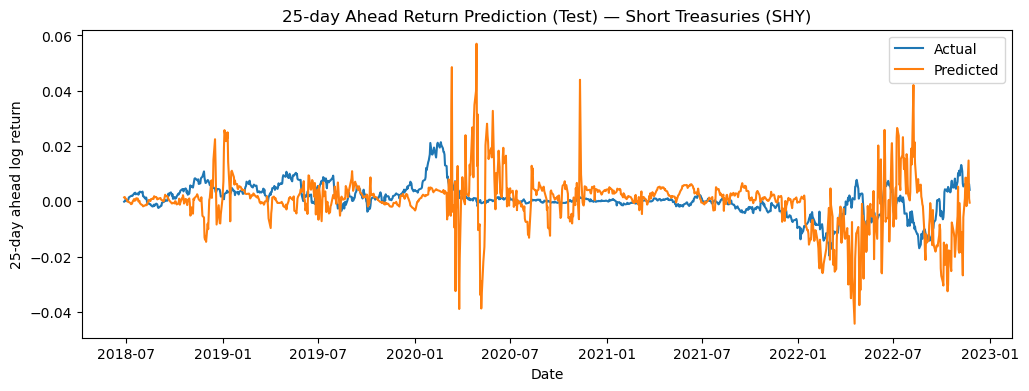

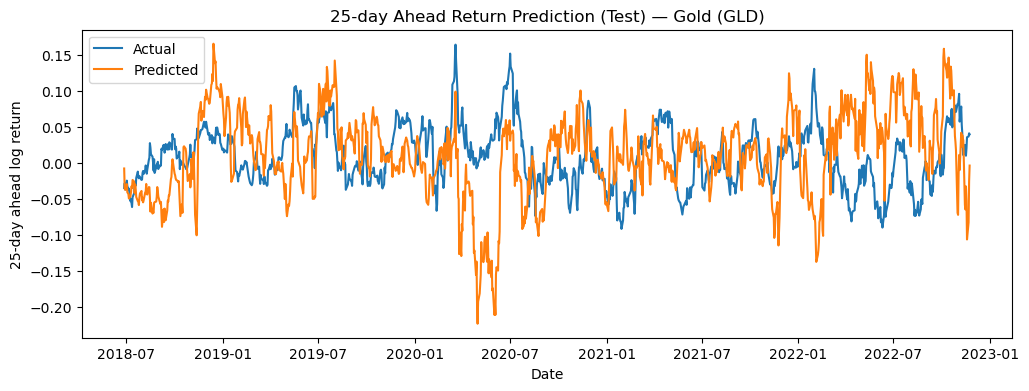

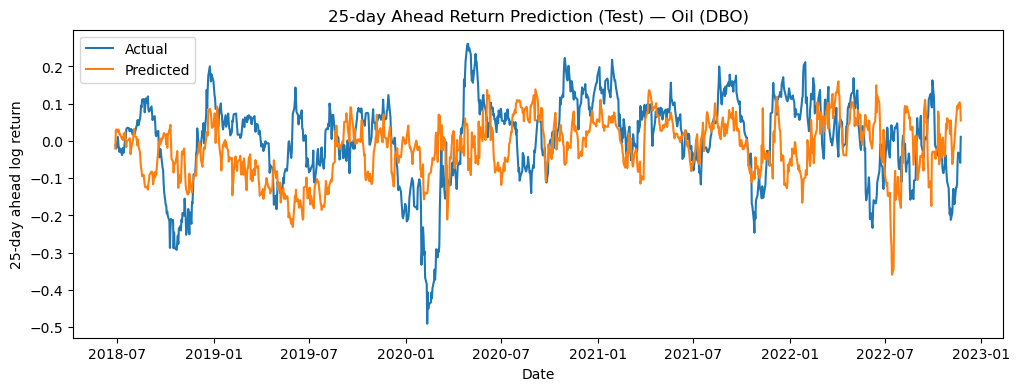

In [10]:
def plot_pred_vs_actual(pred_series, actual_series, asset):
    plt.figure(figsize=(12,4))
    plt.plot(actual_series.index, actual_series.values, label="Actual")
    plt.plot(pred_series.index, pred_series.values, label="Predicted")
    plt.title(f"25-day Ahead Return Prediction (Test) — {asset}")
    plt.xlabel("Date")
    plt.ylabel("25-day ahead log return")
    plt.legend()
    plt.show()

# Use the saved dataframes
preds_test_df = pd.read_csv("outputs/step2_single_output_predictions.csv", index_col=0, parse_dates=True)
actual_test_df = pd.read_csv("outputs/step2_single_output_actuals.csv", index_col=0, parse_dates=True)

for asset in assets:
    plot_pred_vs_actual(preds_test_df[f"pred_{asset}"], actual_test_df[f"actual_{asset}"], asset)

Step 2b/2c: Comparison table across assets (test)

In [11]:
# Extract Test row from each asset metrics table
test_rows = []
for asset, mdf in all_metrics.items():
    row = mdf.loc["Test"].copy()
    row["Asset"] = asset
    test_rows.append(row)

test_summary = pd.DataFrame(test_rows).set_index("Asset").sort_values("RMSE")
test_summary

,MSE,RMSE,MAE,R2,DirectionalAcc
Asset,,,,,
Short Treasuries (SHY),0.000109,0.010443,0.007138,-2.733088,0.544964
Long Treasuries (TLT),0.005229,0.072310,0.055964,-1.181462,0.517986
Gold (GLD),0.005407,0.073530,0.058836,-2.162737,0.449640
Equity (SPY),0.008236,0.090751,0.065873,-1.001179,0.585432
Oil (DBO),0.016103,0.126897,0.102095,-0.238447,0.553957


Load predictions/actuals + align with prices

In [12]:
preds_test_df = pd.read_csv("outputs/step2_single_output_predictions.csv", index_col=0, parse_dates=True)
actual_test_df = pd.read_csv("outputs/step2_single_output_actuals.csv", index_col=0, parse_dates=True)

# Clean column names back to asset labels
preds_test_df.columns = [c.replace("pred_", "") for c in preds_test_df.columns]
actual_test_df.columns = [c.replace("actual_", "") for c in actual_test_df.columns]

# Load adj_close to compute buy&hold benchmark
adj_close = pd.read_csv("data/adj_close.csv", index_col=0, parse_dates=True)

# Keep only test window where predictions exist
common_idx = preds_test_df.index.intersection(actual_test_df.index)
preds_test_df = preds_test_df.loc[common_idx].sort_index()
actual_test_df = actual_test_df.loc[common_idx].sort_index()

preds_test_df.shape, actual_test_df.shape

((1112, 5), (1112, 5))

Define rebalance schedule (every 25 trading days)

In [13]:
H = 25
rebalance_idx = preds_test_df.index[::H]  # every 25th available prediction date
rebalance_idx[:5], len(rebalance_idx)

(DatetimeIndex(['2018-06-27', '2018-08-02', '2018-09-07', '2018-10-12',
                '2018-11-16'],
               dtype='datetime64[ns]', freq=None),
 45)

Build long/short signals from predictions

In [14]:
def build_long_short_weights(pred_row, n_long=2, n_short=2):
    """
    pred_row: pd.Series of predicted 25d returns for all assets at a rebalance date
    Returns: pd.Series weights across assets (sum ~0), equal-weight long & short.
    """
    ranked = pred_row.sort_values(ascending=False)
    longs = ranked.index[:n_long]
    shorts = ranked.index[-n_short:]

    w = pd.Series(0.0, index=pred_row.index)
    w.loc[longs] =  1.0 / n_long
    w.loc[shorts] = -1.0 / n_short
    return w

weights = pd.DataFrame(index=rebalance_idx, columns=preds_test_df.columns, dtype=float)

for dt in rebalance_idx:
    weights.loc[dt] = build_long_short_weights(preds_test_df.loc[dt], n_long=2, n_short=2)

weights.head()

# Transaction cost settings
tc = 0.001  # 10 bps one-way

# Turnover: 0.5 * sum(|w_t - w_{t-1}|)
w_diff = weights.diff().abs()
turnover = 0.5 * w_diff.sum(axis=1)

# First period has no previous weights (assume entering from cash -> full cost)
# Option A (common): set first turnover = 0.5 * sum(|w_0 - 0|)
turnover.iloc[0] = 0.5 * weights.iloc[0].abs().sum()

turnover.head(), turnover.describe()

(2018-06-27    1.0
 2018-08-02    1.5
 2018-09-07    1.0
 2018-10-12    0.5
 2018-11-16    1.5
 dtype: float64,
 count    45.000000
 mean      1.122222
 std       0.534657
 min       0.000000
 25%       1.000000
 50%       1.000000
 75%       1.500000
 max       2.000000
 dtype: float64)

Backtest using realized 25-day forward returns (test)

In [15]:
strategy_gross = []
strategy_net = []

for dt in rebalance_idx:
    w = weights.loc[dt].astype(float)
    realized = actual_test_df.loc[dt].astype(float)

    r_gross = float((w * realized).sum())
    cost = tc * float(turnover.loc[dt])
    r_net = r_gross - cost

    strategy_gross.append(r_gross)
    strategy_net.append(r_net)

strategy_gross = pd.Series(strategy_gross, index=rebalance_idx, name="strategy_gross_25d_logret")
strategy_net   = pd.Series(strategy_net,   index=rebalance_idx, name="strategy_net_25d_logret")

strategy_gross.head(), strategy_net.head()

(2018-06-27    0.041495
 2018-08-02    0.023259
 2018-09-07   -0.059069
 2018-10-12    0.103725
 2018-11-16    0.166377
 Name: strategy_gross_25d_logret, dtype: float64,
 2018-06-27    0.040495
 2018-08-02    0.021759
 2018-09-07   -0.060069
 2018-10-12    0.103225
 2018-11-16    0.164877
 Name: strategy_net_25d_logret, dtype: float64)

Benchmark: equally weighted buy-and-hold (5 ETFs)

To compare fairly at the same 25-day frequency, we compute the realized 25-day forward return of an equally weighted portfolio of the 5 assets (same “holding period” concept).

In [16]:
ew_weights = pd.Series(1/len(actual_test_df.columns), index=actual_test_df.columns)

bench_25d = []
for dt in rebalance_idx:
    realized = actual_test_df.loc[dt].astype(float)
    bench_25d.append(float((ew_weights * realized).sum()))

bench_25d = pd.Series(bench_25d, index=rebalance_idx, name="ew_bh_25d_logret")
bench_25d.head()

2018-06-27   -0.004712
2018-08-02    0.006789
2018-09-07    0.001152
2018-10-12   -0.042187
2018-11-16   -0.040304
Name: ew_bh_25d_logret, dtype: float64

Performance metrics + equity curves

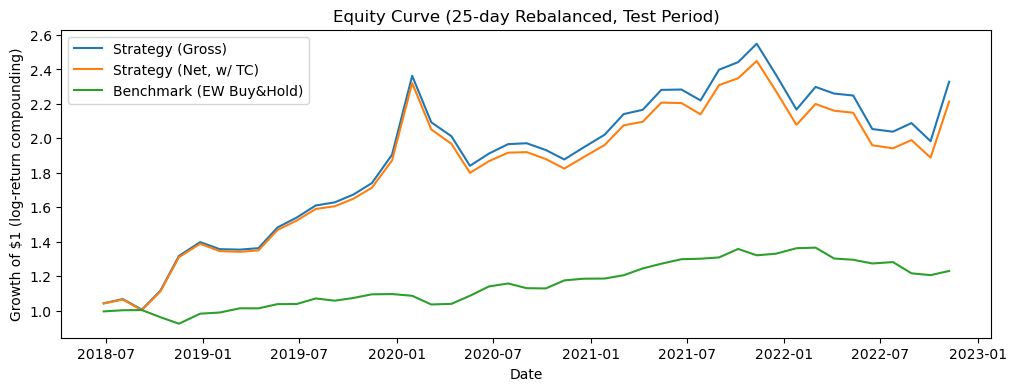

In [17]:
def perf_stats(r_25d, periods_per_year=252/25):
    r = r_25d.dropna()
    mean = r.mean() * periods_per_year
    vol  = r.std()  * np.sqrt(periods_per_year)
    sharpe = mean / vol if vol > 0 else np.nan
    # Max drawdown on equity curve
    eq = np.exp(r.cumsum())
    peak = eq.cummax()
    dd = (eq / peak) - 1.0
    mdd = dd.min()
    return pd.Series({
        "ann_mean_log": mean,
        "ann_vol": vol,
        "sharpe_(rf=0)": sharpe,
        "max_drawdown": mdd,
        "n_periods": len(r)
    })

stats = pd.DataFrame({
    "Strategy (Gross)": perf_stats(strategy_gross),
    "Strategy (Net)": perf_stats(strategy_net),
    "Benchmark (EW B/H)": perf_stats(bench_25d)
})
stats

eq_gross = np.exp(strategy_gross.cumsum())
eq_net   = np.exp(strategy_net.cumsum())
eq_bench = np.exp(bench_25d.cumsum())

plt.figure(figsize=(12,4))
plt.plot(eq_gross.index, eq_gross.values, label="Strategy (Gross)")
plt.plot(eq_net.index, eq_net.values, label="Strategy (Net, w/ TC)")
plt.plot(eq_bench.index, eq_bench.values, label="Benchmark (EW Buy&Hold)")
plt.title("Equity Curve (25-day Rebalanced, Test Period)")
plt.xlabel("Date")
plt.ylabel("Growth of $1 (log-return compounding)")
plt.legend()
plt.show()

In [18]:
avg_turnover = turnover.mean()
total_cost_log = (tc * turnover).sum()

pd.DataFrame({
    "avg_turnover_per_rebalance": [avg_turnover],
    "total_cost_(sum tc*turnover)": [total_cost_log],
    "tc": [tc],
    "n_rebalances": [len(turnover)]
})

,avg_turnover_per_rebalance,total_cost_(sum tc*turnover),tc,n_rebalances
0,1.122222,0.0505,0.001,45


Diagnostic: which assets were chosen most often?

In [19]:
long_counts = pd.Series(0, index=weights.columns, dtype=int)
short_counts = pd.Series(0, index=weights.columns, dtype=int)

for dt in weights.index:
    w = weights.loc[dt]
    long_counts[w > 0] += 1
    short_counts[w < 0] += 1

alloc_summary = pd.DataFrame({
    "long_count": long_counts,
    "short_count": short_counts
}).sort_values("long_count", ascending=False)

alloc_summary

,long_count,short_count
Equity (SPY),22,18
Long Treasuries (TLT),20,13
Gold (GLD),20,14
Oil (DBO),16,23
Short Treasuries (SHY),12,22


Extras

In [ ]:
candidates = [name for name in globals().keys()
              if any(k in name.lower() for k in ["gross", "net", "bench", "strategy", "25d"])
              and isinstance(globals()[name], (pd.Series, pd.DataFrame))]

candidates

Sanity-check periods + date range

In [ ]:
print("gross periods:", len(strategy_gross))
print("net periods:", len(strategy_net))
print("bench periods:", len(bench_25d))

print("date range (gross):", strategy_gross.index.min(), "to", strategy_gross.index.max())
print("date range (net):  ", strategy_net.index.min(), "to", strategy_net.index.max())
print("date range (bench):", bench_25d.index.min(), "to", bench_25d.index.max())

Sanity-check final equity values

In [ ]:
eq_gross = np.exp(strategy_gross.cumsum())
eq_net   = np.exp(strategy_net.cumsum())
eq_bench = np.exp(bench_25d.cumsum())

print("Final equity (gross):", float(eq_gross.iloc[-1]))
print("Final equity (net):  ", float(eq_net.iloc[-1]))
print("Final equity (bench):", float(eq_bench.iloc[-1]))

table 10

In [ ]:
stats_step2 = pd.DataFrame({
    "Strategy (Gross)": perf_stats(strategy_gross),
    "Strategy (Net)": perf_stats(strategy_net),
    "Benchmark (EW B/H)": perf_stats(bench_25d)
})

table10 = stats_step2.loc[["ann_mean_log","ann_vol","sharpe_(rf=0)","max_drawdown"]].T
table10 = table10.rename(columns={
    "ann_mean_log": "Annualized Mean (Log)",
    "ann_vol": "Annualized Volatility",
    "sharpe_(rf=0)": "Sharpe Ratio (rf=0)",
    "max_drawdown": "Max Drawdown"
})
table10["Max Drawdown"] = (table10["Max Drawdown"]*100).round(2).astype(str) + "%"

table10.reset_index().rename(columns={"index":"Metric/Portfolio"})
